# Summary on using VAEs to compress consumer-resource model data

Author: Zhengqing Zhou
Updated: 2026/04/30

In this notebook, we recall the models trained on each dataset from consumer-resource model with different latent dimensions, and quantify the essential dimensionality for reconstructing n_target population dynamics

In [1]:
# We begin by importing the essentials
import os
import numpy as np
import matplotlib.pyplot as plt

# We also setup torch for later usage.
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import trange
from torch.nn import functional as F
from torch import nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import pickle

# Configure GPU if available
if torch.cuda.is_available():

    device = "cuda:0"
else:
    device = "cpu"

display(device)

'cuda:0'

## Visualize the target dynamics

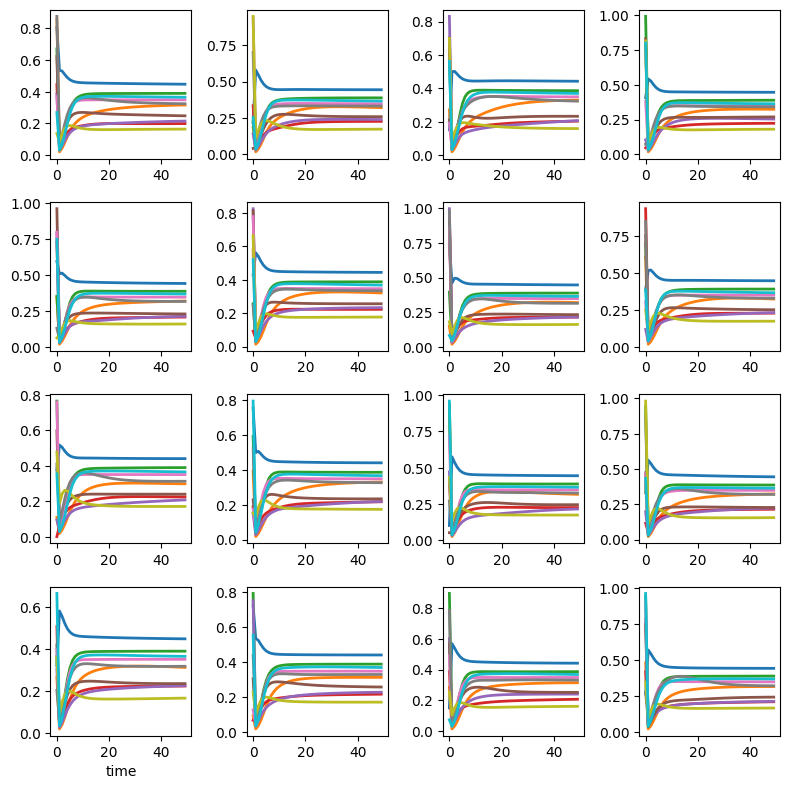

In [2]:
n_target = 10
model_index = 1
X_test = np.load(f"./saved_sims/I{model_index}/resource_T{n_target}_train.npy")
fig,axes=plt.subplots(4,4,figsize=(8,8))
axes=axes.flat
for i,ax in enumerate(axes):
    y_target = X_test[i]
    for j in range(n_target):
        ax.plot(y_target[j,:],lw=2)
ax=axes[12]
ax.set_xlabel("time")
fig.tight_layout()
        

## VAE Network
The VAE network has 32 channels in the encoder, consisting of 3 convolutional layers, each followed by a leaky relu function, with kernel = 3, strid = 1, and padding = 1, so the time series (length of 50) will not get shortened during the convolutions; 1 fully connected linear layer; and another two parallel linear layers to project the encoded time series to the mean value and var of the latent dimension, based on which a gaussian sampling will be done, generating the embedding of the data. The embedding is further decoded by a decoder of the symmetrical structure.

In [3]:
class VAE(nn.Module):

    def __init__(self, n_target, latent_dim):
        # Call parent model constructor and store hidden state variables.
        super().__init__()
        self.latent_dim = latent_dim
        self.n_target = n_target
        self.T = 50
        self.channels = 32

        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=self.n_target, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.Conv1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.Conv1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
        )

        self.mean_map = nn.Linear(self.channels * self.T, self.latent_dim)

        self.std_map = nn.Linear(self.channels * self.T, self.latent_dim)

        self.fc_decoder = nn.Sequential(
            nn.Linear(self.latent_dim, self.channels * self.T),
            nn.LeakyReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.n_target, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU()
        )

    def sample(self, mean, log_var):
        """Sample a given N(0,1) normal distribution given a mean and log of variance."""

        # First compute the variance from the log variance.
        var = torch.exp(0.5 * log_var)

        # Compute a scaled distribution
        eps = torch.randn_like(var)

        # Add the vectors
        z = mean + var * eps

        return z

    def forward(self, X):
        """Forward propogate through the model, return both the reconstruction and sampled mean and standard deviation
        for the system.
        """
        pre_code = self.encoder(X)
        B, C, L = pre_code.shape
        flattened = pre_code.view(B, C * L)

        mu = self.mean_map(flattened)
        log_var = self.std_map(flattened)

        code = self.sample(mu, log_var)

        # Pass through FC layers before decoding
        post_code = self.fc_decoder(code)

        X_hat = self.decoder(post_code.view(B, C, L))

        return X_hat, code, mu, log_var


def vae_loss(x_hat, x, mu, log_var):
    "Compute the sum of BCE and KL loss for the distribution."

    # weight for the KL divergence
    alpha = 1e-4

    # Compute the reconstruction loss
    BCE = F.mse_loss(x_hat, x)

    # Compute the KL divergence of the distribution.
    KLD = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

    return BCE + alpha * KLD

In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [5]:
def get_data(n_target, var_type, model_index):
    X_train = np.load(f"./saved_sims/I{model_index}/{var_type}_T{n_target}_train.npy")
    X_test = np.load(f"./saved_sims/I{model_index}/{var_type}_T{n_target}_test.npy")

    return X_train, X_test

In [6]:
def get_error(model,batch,):
    model.to("cuda:0");
    model.eval()
    with torch.no_grad():
        reconstruction,_,mu,log_var = model(batch.to("cuda:0"))
        reconstruction = reconstruction.cpu()
        mse = F.mse_loss(batch,reconstruction)
        r2 = r2_score(batch.flatten(), reconstruction.flatten())
        kld = (-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()))
    return mse,kld,r2

# A training example

In [7]:
def train_model(model, data_loader, optimizer):
    num_batches = len(data_loader)
    total_loss = 0
    model.train()

    for batch in data_loader:
        batch = batch.to("cuda:0")
        optimizer.zero_grad()
        pred, code, mu, log_var = model(batch)
        loss = vae_loss(pred, batch, mu, log_var)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / num_batches
    return avg_loss

def test_model(model, data_loader):

    num_batches = len(data_loader)
    total_loss = 0

    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to("cuda:0")
            pred, code, mu, log_var = model(batch)
            loss = vae_loss(pred, batch, mu, log_var)
            total_loss += loss.item()

    avg_loss = total_loss / num_batches
    return avg_loss

In [8]:
def run(var_type,n_target,n_embedding,X_train,X_test,model_index,trial=1):
    # set the random seed so the three trials have different initial model weights
    seed = 1000 * n_target + 10*n_embedding + trial
    torch.manual_seed(seed)
    
    lr = 1e-3
    batch_size = 64
    EPOCHS = 100
    
    X_train = torch.Tensor(X_train).float()
    X_test = torch.Tensor(X_test).float()
    train_loader = DataLoader(X_train, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(X_test, batch_size=batch_size, shuffle=False)

    model = VAE(n_target, n_embedding)
    model.to("cuda:0");
    model.train()
    train_losses = []
    test_losses = []
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for ix_epoch in trange(EPOCHS):
        train_err = train_model(model, train_loader, optimizer)
        test_err = test_model(model, test_loader)
        train_losses.append(train_err)
        test_losses.append(test_err)

    print(f"{n_target}-target {var_type} training finished, with starting MSE {test_losses[0]:1.1e}, and ending error {test_losses[-1]:1.1e}")
    return model,train_losses, test_losses

In [9]:
var_type = "species"
n_target = 10

model_index = 1

n_embedding = 30

X_train, X_test = get_data(n_target, var_type, model_index)
model, train_loss, test_loss = run(var_type,n_target,n_embedding,X_train,X_test,model_index)

  0%|          | 0/100 [00:00<?, ?it/s]

10-target species training finished, with starting MSE 4.0e-03, and ending error 1.4e-04


model parameters: 1.6e+05
10-target, 30-embedding; MSE: 6.76e-05, KLD: 7.60e-01, r2:0.998


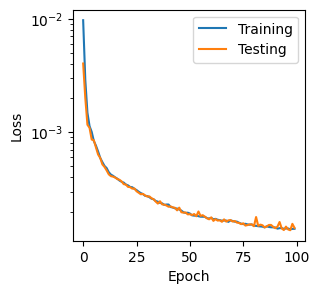

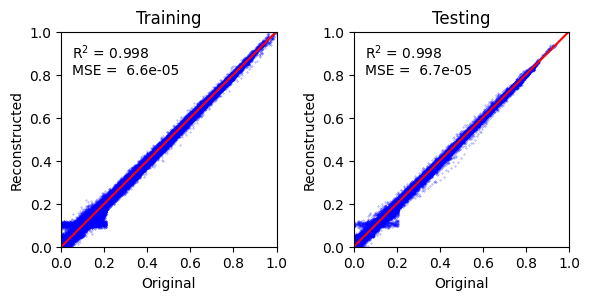

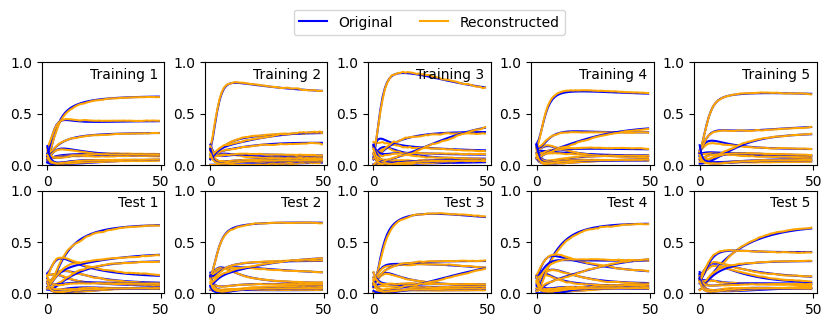

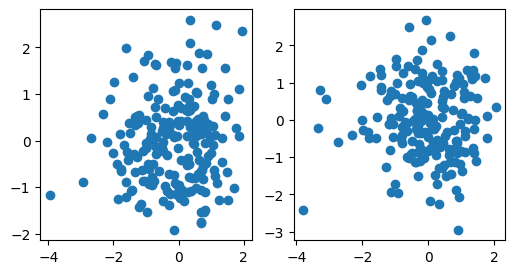

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, TensorDataset

print(f"model parameters: {count_parameters(model):.1e}")
mse_test,kld,r2_test=get_error(model,torch.Tensor(X_test))
print(f"{n_target}-target, {n_embedding}-embedding; MSE: {mse_test:.2e}, KLD: {kld:.2e}, r2:{r2_test:.3f}")
# Plotting the loss values
plt.figure(figsize=(3, 3))
plt.semilogy(train_loss, label='Training')
plt.semilogy(test_loss, label='Testing')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

#rank both train and test data for visualization
train_data=torch.Tensor(X_train)
sums = train_data.var(dim=(1,2))  # Shape: (B,)
ranked_indices_train = torch.argsort(sums,descending=True)  # Sort by total sum


test_data=torch.Tensor(X_test)
sums = test_data.var(dim=(1,2))  # Shape: (B,)
ranked_indices_test = torch.argsort(sums,descending=True)  # Sort by total sum


with torch.no_grad():
    output_train, code_train, _, _ = model(train_data.to(device))
    output_test, code_test, _, _ = model(test_data.to(device))

# Squeeze the output to match the original data dimension
train_data = train_data
test_data = test_data
output_train = output_train
output_test = output_test

output_train = output_train.cpu().numpy()
output_test = output_test.cpu().numpy()

# Percentage of data to visualize
percentage = 0.2
num_train_samples = int(len(train_data) * percentage)
num_test_samples = int(len(test_data) * percentage)

# Index into the data tensors
subset_train_data = train_data[:num_train_samples]
subset_test_data = test_data[:num_test_samples]

subset_train_pred = output_train[:num_train_samples]
subset_test_pred = output_test[:num_test_samples]

# Plotting the reconstructed data against the original data
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

# Training data plot
axs[0].scatter(subset_train_data.flatten(), subset_train_pred.flatten(), s=0.1, color='blue', alpha=0.5)
axs[0].plot([0,1], [0,1], 'r')  # y=x line
axs[0].set_xlim([0,1])
axs[0].set_ylim([0,1])
axs[0].set_aspect('equal', adjustable='box')
axs[0].set_xlabel('Original')
axs[0].set_ylabel('Reconstructed')
axs[0].set_title('Training')

r2_train = r2_score(train_data.flatten(), output_train.flatten())
mse_train = np.square(train_data-output_train).mean()
axs[0].text(0.05, 0.95, f'R$^2$ = {r2_train:.3f}\nMSE = {mse_train: .1e}', transform=axs[0].transAxes, verticalalignment='top')

# Testing data plot
axs[1].scatter(subset_test_data.flatten(), subset_test_pred.flatten(), s=0.1, color='blue', alpha=0.5)
axs[1].plot([0,1], [0,1], 'r')  # y=x line
axs[1].set_xlim([0,1])
axs[1].set_ylim([0,1])
axs[1].set_aspect('equal', adjustable='box')
axs[1].set_xlabel('Original')
axs[1].set_ylabel('Reconstructed')
axs[1].set_title('Testing')

r2_test = r2_score(test_data.flatten(), output_test.flatten())
mse_test = np.square(test_data-output_test).mean()
axs[1].text(0.05, 0.95, f'R$^2$ = {r2_test:.3f}\nMSE = {mse_test: .1e}', transform=axs[1].transAxes, verticalalignment='top')

plt.tight_layout()

# Additional Panels for Sample Data Trajectories
fig, axs = plt.subplots(2, 5, figsize=(10, 3))

# Training data trajectories
idx_show = np.random.choice(np.arange(train_data.shape[0]),5,replace=False)
for i,idx in enumerate(idx_show):
    for j in range(n_target):
        axs[0, i].plot(train_data[idx,j], color='blue')
        axs[0, i].plot(output_train[idx,j], color='orange')
    axs[0, i].text(x=0.95,y=0.95,s=f'Training {i + 1}',ha="right",va="top",transform=axs[0,i].transAxes)
    axs[0, i].set_ylim([0,1])
axs[0,2].plot([], label='Original', color='blue')
axs[0,2].plot([], label='Reconstructed', color='orange')
axs[0,2].legend(loc="lower center",bbox_to_anchor=(0.5,1.2),ncol=2)
# Testing data trajectories
idx_show = np.random.choice(np.arange(test_data.shape[0]),5,replace=False)
for i,idx in enumerate(idx_show):
    for j in range(n_target):
        axs[1, i].plot(test_data[idx,j], color='blue')
        axs[1, i].plot(output_test[idx,j], color='orange')
    axs[1, i].text(x=0.95,y=0.95,s=f'Test {i + 1}',ha="right",va="top",transform=axs[1,i].transAxes)
    axs[1, i].set_ylim([0,1])

plt.subplots_adjust(hspace=0.25,wspace=0.33)
plt.show()

fig,axes=plt.subplots(1,2,figsize=(6,3))
ax1,ax2=axes
code_train = code_train.cpu()
code_test = code_test.cpu()
ax1.scatter(code_train[0:200,0],code_train[0:200,1])
ax2.scatter(code_test[0:200,0],code_test[0:200,1])

# Visualize the reconstruction of a given trained model

R2: 0.93, mse: 5.39e-04


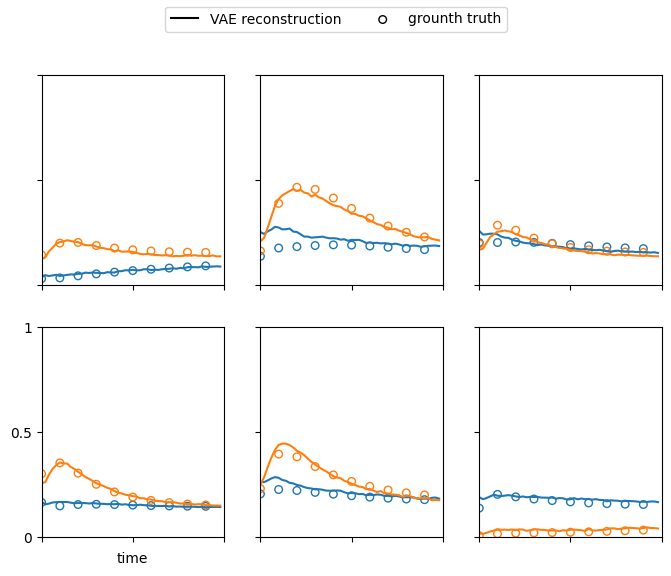

In [11]:
var_type = "species"
model_index=1
n_target=2
trial=1
x=np.arange(0,50,1)
n_embedding = 2

X_train, X_test = get_data(n_target, var_type, model_index)

batch=torch.Tensor(X_train).float()
n_show=6
tp_show=np.arange(0,50,5)
fig,axes=plt.subplots(2,3,figsize=(8,6))
axes=axes.flat

model = VAE(n_target,n_embedding)
model.to("cuda:0");
model.load_state_dict(
    torch.load(
        f"./vae_models/I{model_index}/mcrm_{var_type}_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True)
)
model.eval()

loss=0
with torch.no_grad():
    pred, code, mu, log_var = model(batch.to(device))
    pred=pred.cpu()
    loss=F.mse_loss(batch,pred).item()
r2 = r2_score(batch.flatten(),pred.flatten())
print(f"R2: {r2:.2f}, mse: {loss:.2e}")
np.random.seed(42)
idx_show = np.random.choice(np.arange(batch.shape[0]),n_show,replace=False)
for i,ii in enumerate(idx_show):
    ax=axes[i]
    data=batch[ii]
    rec=pred[ii]
    for k in range(n_target):
        l=ax.plot(x,rec[k,:],linewidth=1.5)
        ax.scatter(x[tp_show],data[k,tp_show],s=30,edgecolor=l[-1].get_color(),facecolor="None")
        ax.set_xlim([0,50])
        ax.set_xticks([0,25,50])
        ax.set_xticklabels([])
        ax.set_yticks([0,0.5,1])
        ax.set_yticklabels([])
    ax.set_ylim([0,1])
ax=axes[3]
ax.set_xticklabels([])
ax.set_xlabel("time")
ax.set_yticklabels([0,0.5,1])
ax.plot([],[],c="k",linewidth=1.5,label="VAE reconstruction")
ax.scatter([],[],s=30,edgecolor="k",facecolor="None",label="grounth truth")
fig.legend(loc="upper center",ncol=2)

# Effective dimension of observable dynamics in consumer-resource model

We define a function `get_error` which will return the MSE loss of the reconstruction of a `n_target` variables (could be `species` or `resources`)using an `n_embedding` dimensional VAE model. By iterating through all the parameters, we can then determine the essential dimensionality for the reconstruction of a given size target population dynamics.


In [3]:
def get_error(model,batch,):
    model.to("cuda:0");
    model.eval()
    with torch.no_grad():
        reconstruction,_,mu,log_var = model(batch.to("cuda:0"))
        reconstruction = reconstruction.cpu()
        mse = F.mse_loss(batch,reconstruction)
        r2 = r2_score(batch.flatten(), reconstruction.flatten())
        kld = (-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()))
    return mse,kld,r2

## target species

In [8]:
var_type = "species"

NT=np.arange(1,11,1)
N_EBD = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30]
for i,n_target in enumerate(NT):
    for model_index in [1,2,3]:
        data_train = np.zeros((6,len(N_EBD)))
        data_train[0,:] = N_EBD
        data_test = np.zeros((6,len(N_EBD)))
        data_test[0,:] = N_EBD
        X_train, X_test = get_data(n_target, var_type, model_index)
        batch_train = torch.Tensor(X_train).float()
        batch_test = torch.Tensor(X_test).float()
        for trial in range(1,6,1):
            for j,n_embedding in enumerate(N_EBD):
                model = VAE(n_target,n_embedding)
                model.to("cuda:0");
                model.load_state_dict(
                    torch.load(
                        f"./vae_models/I{model_index}/mcrm_{var_type}_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True)
                )
                mse_train,kld,r2_train=get_error(model,batch_train)
                data_train[trial,j]=(1-r2_train)*100
                mse_test,kld,r2_test=get_error(model,batch_test)
                data_test[trial,j]=(1-r2_test)*100
        save_dir = f"./saved_data/{var_type}/I{model_index}"
        os.makedirs(save_dir, exist_ok=True)
        np.savetxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_train.txt", data_train)
        np.savetxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_test.txt", data_test)
        print(f"model {model_index}; species target {n_target} finished")

model 1; species target 1 finished
model 2; species target 1 finished
model 3; species target 1 finished
model 1; species target 2 finished
model 2; species target 2 finished
model 3; species target 2 finished
model 1; species target 3 finished
model 2; species target 3 finished
model 3; species target 3 finished
model 1; species target 4 finished
model 2; species target 4 finished
model 3; species target 4 finished
model 1; species target 5 finished
model 2; species target 5 finished
model 3; species target 5 finished
model 1; species target 6 finished
model 2; species target 6 finished
model 3; species target 6 finished
model 1; species target 7 finished
model 2; species target 7 finished
model 3; species target 7 finished
model 1; species target 8 finished
model 2; species target 8 finished
model 3; species target 8 finished
model 1; species target 9 finished
model 2; species target 9 finished
model 3; species target 9 finished
model 1; species target 10 finished
model 2; species ta

Text(0, 0.5, 'FUV%')

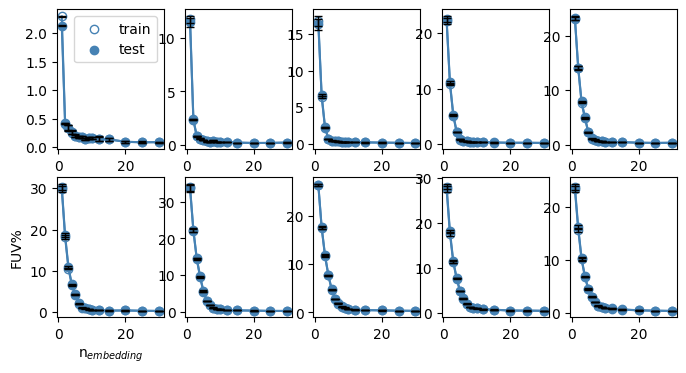

In [9]:
NT=np.arange(1,11,1)
var_type = "species"
n_trial = 5
model_index=1
fig,axes=plt.subplots(2,5,figsize=(8,4))
axes=axes.flat
for i,n_target in enumerate(NT):
    ax=axes[i]
    data_train = np.loadtxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_train.txt")
    data_test=np.loadtxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_test.txt")
    N_EBD = data_train[0,:]
    for j,data in enumerate([data_train,data_test]):
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        mfc = 'white' if j==0 else 'steelblue'
        ax.scatter(N_EBD,mean_FUV,facecolor=mfc,edgecolor='steelblue')
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
        ax.plot(N_EBD,mean_FUV,c='steelblue')
ax=axes[0]
ax.scatter([],[],facecolor='white',edgecolor='steelblue',label='train')
ax.scatter([],[],facecolor='steelblue',edgecolor='steelblue',label='test')
ax.legend()
ax=axes[5]
ax.set_xlabel("n$_{embedding}$")
ax.set_ylabel("FUV%")

Now fit the FUV-embedding relationship to an exponential threshold function

In [4]:
from scipy.optimize import curve_fit

def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y

[3.56297101 1.05969352 0.27893458]
[5.21165629 0.68206673 0.48107407]
[4.70791843 0.79735838 0.18768794]
[5.77522108 0.66928556 0.26720898]
[6.72712383 0.53890675 0.34731838]
[7.95265313 0.45226851 0.43989755]
[8.61354753 0.43989148 0.46047447]
[8.87719288 0.37399203 0.57331248]
[10.60768483  0.3315328   0.42549791]
[9.9502346  0.34163456 0.50725997]


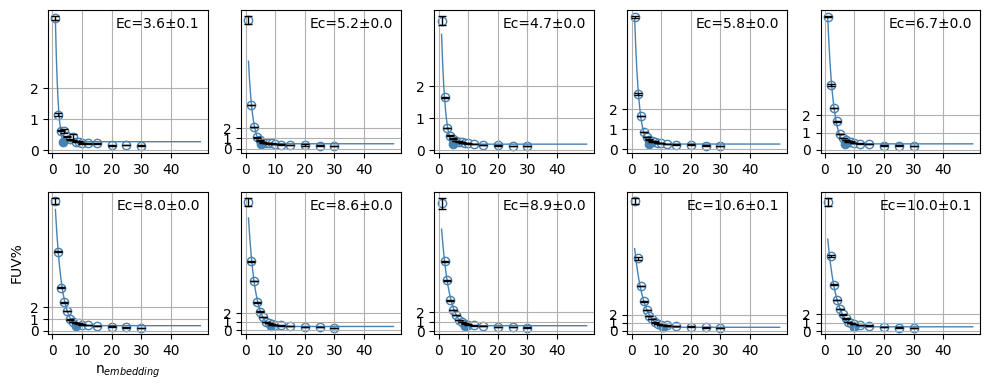

In [7]:
NT=np.arange(1,11,1)
var_type = "species"
n_trial = 5
model_index = 2
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    data=np.loadtxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_test.txt")
    N_EBD=data[0,:]
    FUV = data[1:,:]
    mean_FUV = np.mean(FUV,axis=0)
    std_FUV = np.std(FUV,axis=0,ddof=1)
    se_FUV = std_FUV/np.sqrt(n_trial)
    ax.scatter(N_EBD,mean_FUV,fc='white',ec='steelblue')
    ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
    
    popt, pcov = curve_fit(y_exp, N_EBD, mean_FUV, sigma=se_FUV, absolute_sigma=True, p0=(n_target, 1, 0.1))
    print(popt)
    Ec = popt[0]
    param_errors = np.sqrt(np.diag(pcov))# estimate the standard errors of the fitted parameters
    Ec_se = param_errors[0]
    Ec_data[1,i]=Ec
    Ec_data[2,i]=Ec_se
    y_Ec = y_exp(np.array([Ec]),*popt)
    ax.scatter(Ec,y_Ec,c='steelblue')
    xx=np.linspace(1,50,1000)
    yy=y_exp(xx,*popt)
    ax.plot(xx,yy,color="steelblue",linewidth=1)
    
    ax.text(x=0.95,y=0.95,s="Ec=%1.1f±%1.1f"%(Ec,Ec_se),ha="right",va="top",transform=ax.transAxes)
    if i==5:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
    ax.set_xticks(np.arange(0,50,10))
    ax.set_yticks(np.arange(0,3,1))
    ax.grid(True)
fig.tight_layout()
np.savetxt(f"./saved_data/{var_type}/Ec_{var_type}_model{model_index}.txt",Ec_data)

MCRM species Community 1
Slope            : 1.015 ± 0.004 (SE)
Intercept        : 2.027 ± 0.021 (SE)
t-statistic      : 233.59  (dof = 8)
p-value (slope≠0): 0
Weighted R²      : 0.964
MCRM species Community 2
Slope            : 0.789 ± 0.005 (SE)
Intercept        : 2.797 ± 0.029 (SE)
t-statistic      : 148.36  (dof = 8)
p-value (slope≠0): 4.88e-15
Weighted R²      : 0.948
MCRM species Community 3
Slope            : 0.944 ± 0.004 (SE)
Intercept        : 2.186 ± 0.017 (SE)
t-statistic      : 254.54  (dof = 8)
p-value (slope≠0): 0
Weighted R²      : 0.942


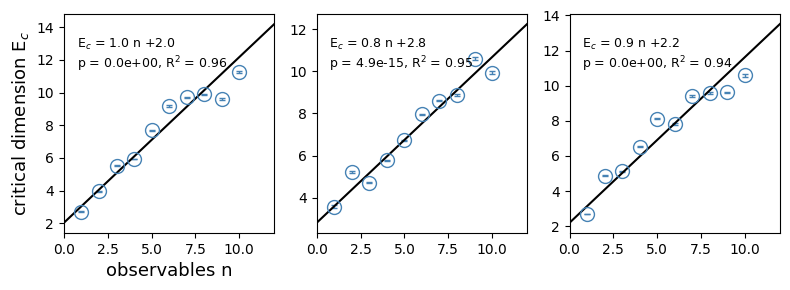

In [8]:
from scipy.optimize import curve_fit
from scipy.stats import t

# Linear model
def linear_model(x, a, b):
    return a * x + b

fig,axes = plt.subplots(1,3,figsize=(8,3))
axes=axes.flat
for i,model_index in enumerate([1,2,3]):
    ax=axes[i]
    data = np.loadtxt(f"./saved_data/{var_type}/Ec_{var_type}_model{model_index}.txt")
    # Extract x, y, and CI bounds
    N_TG = data[0,:]
    Ec = data[1,:]
    Ec_se = data[2,:]
    ax.errorbar(N_TG,Ec,Ec_se,marker="o",c='steelblue',mfc="None",capsize=2,lw=0,markersize=10,
                    elinewidth=1)
    
    # Weighted fit using standard errors
    popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
    slope, intercept = popt
    slope_se, intercept_se = np.sqrt(np.diag(pcov))

    # residuals and total sums of squares
    y_pred = linear_model(N_TG, slope, intercept)
    SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
    SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)
    
    R2 = 1 - SS_res / SS_tot
    
    # Compute t-statistic and p-value
    dof = len(N_TG) - 2
    t_stat = slope / slope_se
    p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))
    
    # Generate fit line and CI band
    x_fit = np.linspace(0, 12, 100)
    y_fit = linear_model(x_fit, slope, intercept)

    ax.plot(x_fit,y_fit,c="k")
    ax.set_xlim([0, 12])
    
    # ----- formatted report ---------------------------------------------------
    print(f"MCRM {var_type} Community {model_index}")
    report = (
        f"Slope            : {slope:.3f} ± {slope_se:.3f} (SE)\n"
        f"Intercept        : {intercept:.3f} ± {intercept_se:.3f} (SE)\n"
        f"t-statistic      : {t_stat:.2f}  (dof = {dof})\n"
        f"p-value (slope≠0): {p_value:.3g}\n"
        f"Weighted R²      : {R2:.3f}"
    )

    print(report)

    # Format regression equation
    txt = (f"E$_c$ = {slope:.1f} n {intercept:+.1f}\n"
       f"p = {p_value:.1e}, R$^2$ = {R2:.2f}")
    ax.text(x=0.06, y=0.75, s=txt, transform=ax.transAxes, fontsize=9)
    #ax.text(x=0.11,y=0.85,s=txt,transform=ax.transAxes, fontsize=10)
ax=axes[0]
ax.set_xlabel("observables n", fontsize=13)
ax.set_ylabel("critical dimension E$_c$", fontsize=13)
fig.tight_layout()

## Target resource dynamics

In [15]:
var_type = "resource"

NT=np.arange(1,11,1)
N_EBD = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]
for i,n_target in enumerate(NT):
    for model_index in [1,2,3]:
        data_train = np.zeros((6,len(N_EBD)))
        data_train[0,:] = N_EBD
        data_test = np.zeros((6,len(N_EBD)))
        data_test[0,:] = N_EBD
        X_train, X_test = get_data(n_target, var_type, model_index)
        batch_train = torch.Tensor(X_train).float()
        batch_test = torch.Tensor(X_test).float()
        for trial in range(1,6,1):
            for j,n_embedding in enumerate(N_EBD):
                model = VAE(n_target,n_embedding)
                model.to("cuda:0");
                model.load_state_dict(
                    torch.load(
                        f"./vae_models/I{model_index}/mcrm_{var_type}_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True)
                )
                mse_train,kld,r2_train=get_error(model,batch_train)
                data_train[trial,j]=(1-r2_train)*100
                mse_test,kld,r2_test=get_error(model,batch_test)
                data_test[trial,j]=(1-r2_test)*100
        save_dir = f"./saved_data/{var_type}/I{model_index}"
        os.makedirs(save_dir, exist_ok=True)
        np.savetxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_train.txt", data_train)
        np.savetxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_test.txt", data_test)
        print(f"model {model_index}; {var_type} target {n_target} finished")

model 1; resource target 1 finished
model 2; resource target 1 finished
model 3; resource target 1 finished
model 1; resource target 2 finished
model 2; resource target 2 finished
model 3; resource target 2 finished
model 1; resource target 3 finished
model 2; resource target 3 finished
model 3; resource target 3 finished
model 1; resource target 4 finished
model 2; resource target 4 finished
model 3; resource target 4 finished
model 1; resource target 5 finished
model 2; resource target 5 finished
model 3; resource target 5 finished
model 1; resource target 6 finished
model 2; resource target 6 finished
model 3; resource target 6 finished
model 1; resource target 7 finished
model 2; resource target 7 finished
model 3; resource target 7 finished
model 1; resource target 8 finished
model 2; resource target 8 finished
model 3; resource target 8 finished
model 1; resource target 9 finished
model 2; resource target 9 finished
model 3; resource target 9 finished
model 1; resource target 10 

Text(0, 0.5, 'FUV%')

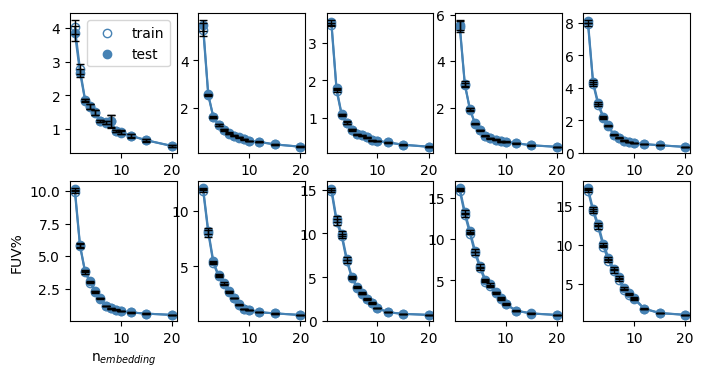

In [16]:
NT=np.arange(1,11,1)
var_type = "resource"
n_trial = 5
model_index=2
fig,axes=plt.subplots(2,5,figsize=(8,4))
axes=axes.flat
for i,n_target in enumerate(NT):
    ax=axes[i]
    data_train = np.loadtxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_train.txt")
    data_test=np.loadtxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_test.txt")
    N_EBD = data_train[0,:]
    for j,data in enumerate([data_train,data_test]):
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        mfc = 'white' if j==0 else 'steelblue'
        ax.scatter(N_EBD,mean_FUV,facecolor=mfc,edgecolor='steelblue')
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
        ax.plot(N_EBD,mean_FUV,c='steelblue')
ax=axes[0]
ax.scatter([],[],facecolor='white',edgecolor='steelblue',label='train')
ax.scatter([],[],facecolor='steelblue',edgecolor='steelblue',label='test')
ax.legend()
ax=axes[5]
ax.set_xlabel("n$_{embedding}$")
ax.set_ylabel("FUV%")

In [9]:
from scipy.optimize import curve_fit

def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y

[4.44905322 0.36174348 0.95986103]
[2.80406157 1.20115459 0.57074896]
[3.80126658 0.73116689 0.91891126]
[4.80209667 0.6283653  0.93719111]
[5.91491803 0.53474673 0.95573533]
[9.06352853 0.29683447 1.09340518]
[7.85995863 0.36515154 1.44462343]
[9.76565021 0.30582432 1.1202074 ]
[10.96904529  0.27238352  1.20072605]
[13.46898254  0.22851149  1.13167697]


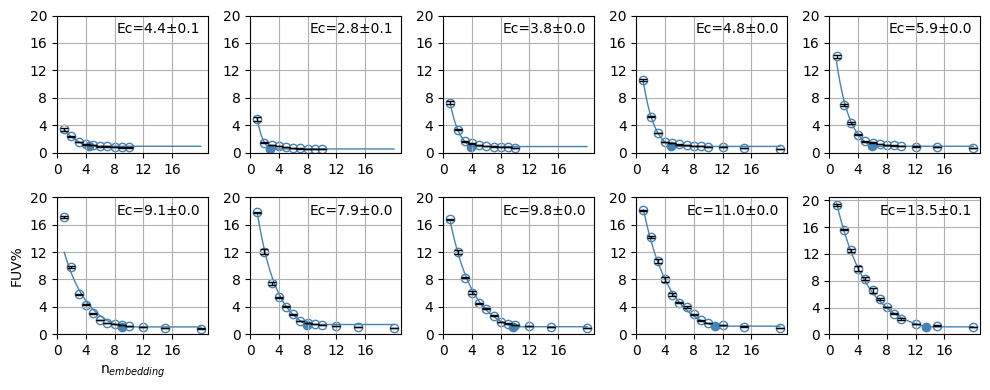

In [12]:
var_type = "resource"
NT=np.arange(1,11,1)
n_trial = 5
model_index = 3
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    data=np.loadtxt(f"./saved_data/{var_type}/I{model_index}/reconstruction_T{n_target}_{var_type}_test.txt")
    N_EBD=data[0,:]
    FUV = data[1:,:]
    if n_target<=3: # for small target size, fitting with smaller embedding dimensions empirically gives better fits
        idx = (N_EBD<=10)
        N_EBD = N_EBD[idx]
        FUV = FUV[:,idx]
    mean_FUV = np.mean(FUV,axis=0)
    std_FUV = np.std(FUV,axis=0,ddof=1)
    se_FUV = std_FUV/np.sqrt(n_trial)
    ax.scatter(N_EBD,mean_FUV,fc='white',ec='steelblue')
    ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
    
    popt, pcov = curve_fit(y_exp, N_EBD, mean_FUV, sigma=se_FUV, absolute_sigma=True, p0=(n_target, 0.5, 0.5))
    print(popt)
    Ec = popt[0]
    param_errors = np.sqrt(np.diag(pcov))# estimate the standard errors of the fitted parameters
    Ec_se = param_errors[0]
    Ec_data[1,i]=Ec
    Ec_data[2,i]=Ec_se
    y_Ec = y_exp(np.array([Ec]),*popt)
    ax.scatter(Ec,y_Ec,c='steelblue')
    xx=np.linspace(1,20,1000)
    yy=y_exp(xx,*popt)
    ax.plot(xx,yy,color="steelblue",linewidth=1)
    
    ax.text(x=0.95,y=0.95,s="Ec=%1.1f±%1.1f"%(Ec,Ec_se),ha="right",va="top",transform=ax.transAxes)
    if i==5:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
    ax.set_xticks(np.arange(0,20,4))
    ax.set_yticks(np.arange(0,24,4))
    ax.grid(True)
fig.tight_layout()
np.savetxt(f"./saved_data/{var_type}/Ec_{var_type}_model{model_index}.txt",Ec_data)

MCRM resource Community 1
Slope            : 1.238 ± 0.005 (SE)
Intercept        : 0.841 ± 0.032 (SE)
t-statistic      : 264.97  (dof = 8)
p-value (slope≠0): 0
Weighted R²      : 0.975
MCRM resource Community 2
Slope            : 1.313 ± 0.008 (SE)
Intercept        : 1.569 ± 0.052 (SE)
t-statistic      : 165.09  (dof = 8)
p-value (slope≠0): 2e-15
Weighted R²      : 0.926
MCRM resource Community 3
Slope            : 1.156 ± 0.004 (SE)
Intercept        : 0.505 ± 0.028 (SE)
t-statistic      : 267.90  (dof = 8)
p-value (slope≠0): 0
Weighted R²      : 0.880


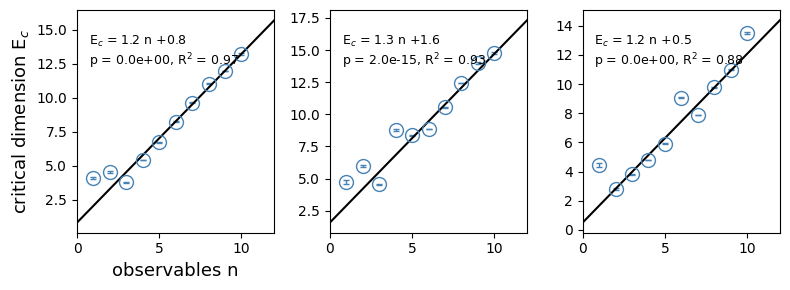

In [13]:
from scipy.optimize import curve_fit
from scipy.stats import t

# Linear model
def linear_model(x, a, b):
    return a * x + b

var_type = "resource"
fig,axes = plt.subplots(1,3,figsize=(8,3))
axes=axes.flat
for i,model_index in enumerate([1,2,3]):
    ax=axes[i]
    data = np.loadtxt(f"./saved_data/{var_type}/Ec_{var_type}_model{model_index}.txt")
    # Extract x, y, and CI bounds
    N_TG = data[0,:]
    Ec = data[1,:]
    Ec_se = data[2,:]
    ax.errorbar(N_TG,Ec,Ec_se,marker="o",c='steelblue',mfc="None",capsize=2,lw=0,markersize=10,
                    elinewidth=1)
    
    # Weighted fit using standard errors
    popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
    slope, intercept = popt
    slope_se, intercept_se = np.sqrt(np.diag(pcov))

    # residuals and total sums of squares
    y_pred = linear_model(N_TG, slope, intercept)
    SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
    SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)
    
    R2 = 1 - SS_res / SS_tot
    
    # Compute t-statistic and p-value
    dof = len(N_TG) - 2
    t_stat = slope / slope_se
    p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))
    
    # Generate fit line and CI band
    x_fit = np.linspace(0, 12, 100)
    y_fit = linear_model(x_fit, slope, intercept)

    ax.plot(x_fit,y_fit,c="k")
    ax.set_xlim([0, 12])
    
    # ----- formatted report ---------------------------------------------------
    print(f"MCRM {var_type} Community {model_index}")
    report = (
        f"Slope            : {slope:.3f} ± {slope_se:.3f} (SE)\n"
        f"Intercept        : {intercept:.3f} ± {intercept_se:.3f} (SE)\n"
        f"t-statistic      : {t_stat:.2f}  (dof = {dof})\n"
        f"p-value (slope≠0): {p_value:.3g}\n"
        f"Weighted R²      : {R2:.3f}"
    )

    print(report)

    # Format regression equation
    txt = (f"E$_c$ = {slope:.1f} n {intercept:+.1f}\n"
       f"p = {p_value:.1e}, R$^2$ = {R2:.2f}")
    ax.text(x=0.06, y=0.75, s=txt, transform=ax.transAxes, fontsize=9)
    #ax.text(x=0.11,y=0.85,s=txt,transform=ax.transAxes, fontsize=10)
ax=axes[0]
ax.set_xlabel("observables n", fontsize=13)
ax.set_ylabel("critical dimension E$_c$", fontsize=13)
fig.tight_layout()